In [ ]:
import kagglehub

In [ ]:
path = kagglehub.dataset_download("entrepreneurlife/personal-finance")

print("Path to dataset files:", path)

100%|██████████| 30.6k/30.6k [00:00<00:00, 32.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/entrepreneurlife/personal-finance/versions/2


In [ ]:
import pandas as pd
import os

# Load your data
df = pd.read_excel(os.path.join(path, 'personal_transactions_dashboard_ready (2).xlsx'))

# Check for missing values and data types
print(df.info())

# See the total spend vs. total income
print(df.groupby('Transaction Type')['Amount'].sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              806 non-null    datetime64[ns]
 1   Description       806 non-null    object        
 2   Amount            806 non-null    float64       
 3   Transaction Type  806 non-null    object        
 4   Category          806 non-null    object        
 5   Account Name      806 non-null    object        
 6   Month             806 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 44.2+ KB
None
Transaction Type
credit    124269.76
debit      96083.78
Name: Amount, dtype: float64


In [18]:
needs = ['Rent', 'Utilities', 'Groceries', 'Insurance', 'Gas']
wants = ['Entertainment', 'Dining Out', 'Shopping', 'Travel', 'Subscriptions']

def classify_spend(row):
    if row['Category'] in needs:
        return 'Need'
    elif row['Category'] in wants:
        return 'Want'
    else:
        return 'Other/Savings'

df['Spend_Class'] = df.apply(classify_spend, axis=1)

In [ ]:
# Assuming you already created the 'Spend_Class' column from our last step
# and ensured 'Amount' is positive for expenses and income.

# 1. Create a pivot table to see monthly totals per category
monthly_summary = df.groupby(['Month', 'Spend_Class'])['Amount'].sum().unstack().fillna(0)

# Calculate total monthly income from 'credit' transactions
monthly_income = df[df['Transaction Type'] == 'credit'].groupby('Month')['Amount'].sum()

# Add 'Income' to monthly_summary, aligning by index (Month)
monthly_summary['Income'] = monthly_income
monthly_summary['Income'] = monthly_summary['Income'].fillna(0) # Fill any NaNs if a month has no income

# 2. Calculate the Ratio
monthly_summary['Inflation_Metric'] = (monthly_summary['Want'] / monthly_summary['Income']) * 100

In [ ]:
print("Transaction Types:", df['Transaction Type'].unique())
print("Categories:", df['Category'].unique())

Transaction Types: ['debit' 'credit']
Categories: ['Shopping' 'Mortgage & Rent' 'Restaurants' 'Credit Card Payment'
 'Movies & Dvds' 'Home Improvement' 'Utilities' 'Music' 'Mobile Phone'
 'Gas & Fuel' 'Groceries' 'Paycheck' 'Fast Food' 'Coffee Shops' 'Internet'
 'Haircut' 'Alcohol & Bars' 'Auto Insurance' 'Entertainment'
 'Food & Dining' 'Television' 'Electronics & Software']


In [ ]:
import pandas as pd

# --- PRE-STEP: Clean the Transaction Type column just in case ---
df['Transaction Type'] = df['Transaction Type'].str.strip().str.lower()

# 1. Create the Income dataframe
# Note: I'm using 'credit' because it's the standard label for money in.
income_df = df[df['Transaction Type'] == 'credit'].copy()

# 2. Create the Expense dataframe (the 'debit' transactions)
expense_df = df[df['Transaction Type'] == 'debit'].copy()

# 3. Group by Month to get totals for both
monthly_income = income_df.groupby('Month')['Amount'].sum().reset_index()
monthly_income.rename(columns={'Amount': 'Monthly_Income'}, inplace=True)

monthly_expenses = expense_df.groupby('Month')['Amount'].sum().reset_index()
monthly_expenses.rename(columns={'Amount': 'Monthly_Expenses'}, inplace=True)

# 4. MERGE: Combine income and expenses into one "Summary" table
monthly_summary = pd.merge(monthly_expenses, monthly_income, on='Month', how='left')

# 5. FILL GAPS: If a month has no income, fill it with 0 instead of NaN
monthly_summary['Monthly_Income'] = monthly_summary['Monthly_Income'].fillna(0)

# 6. CALCULATE: Add your Lifestyle Inflation Metric
# (What percentage of income is being spent?)
monthly_summary['Burn_Rate_%'] = (monthly_summary['Monthly_Expenses'] / monthly_summary['Monthly_Income']) * 100

# --- THE CALL FUNCTIONS ---
# This part makes the results appear on your screen
print("--- PROJECT SUMMARY TABLE ---")
display(monthly_summary)

# Quick sanity check: Do we have any income?
print(f"\nTotal Records processed: {len(df)}")
print(f"Total Income found: ${monthly_summary['Monthly_Income'].sum():,.2f}")

--- PROJECT SUMMARY TABLE ---


,Month,Monthly_Expenses,Monthly_Income,Burn_Rate_%
0,2018-01,2931.45,7162.89,40.925520
1,2018-02,3165.05,5220.75,60.624431
2,2018-03,3500.16,7321.50,47.806597
3,2018-04,6029.54,7166.88,84.130612
4,2018-05,11392.03,5091.55,223.743850
5,2018-06,3665.88,6017.19,60.923454
6,2018-07,2968.98,4666.34,63.625454
7,2018-08,2396.18,7379.15,32.472304
8,2018-09,3286.99,5234.71,62.792208
9,2018-10,2848.35,5022.23,56.714846



Total Records processed: 806
Total Income found: $124,269.76


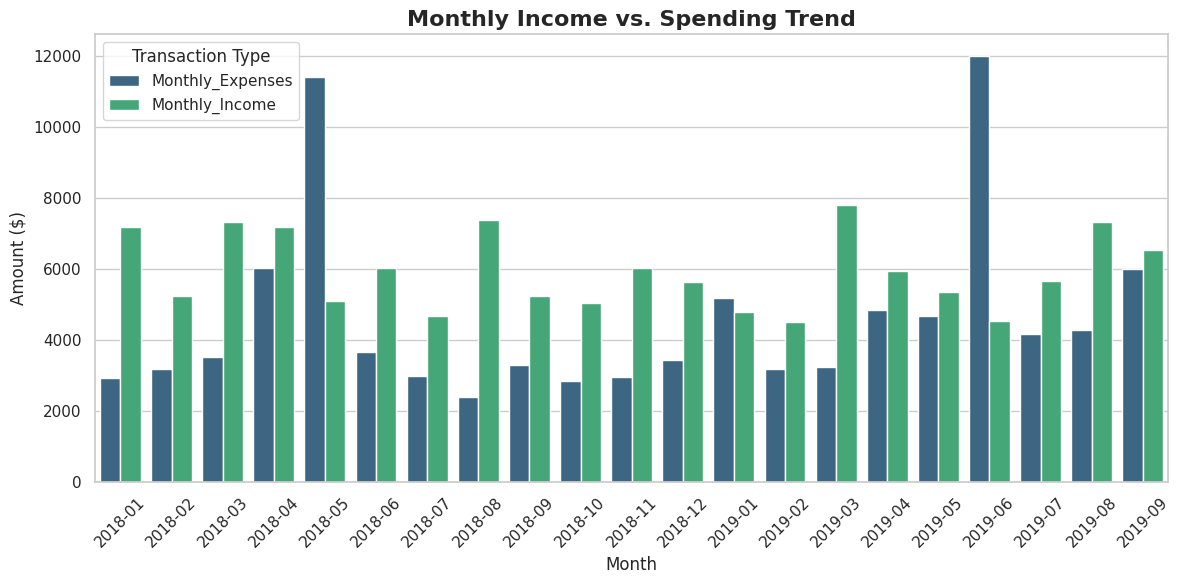

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 2. Create a "Melted" version of the table for easier plotting
# This turns Income and Expenses into one column so Seaborn can compare them
plot_data = monthly_summary.melt(id_vars='Month', value_vars=['Monthly_Expenses', 'Monthly_Income'],
                                  var_name='Type', value_name='Amount')

# 3. Create the Bar Chart
ax = sns.barplot(data=plot_data, x='Month', y='Amount', hue='Type', palette='viridis')

# 4. Add Titles and Labels
plt.title('Monthly Income vs. Spending Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)
plt.xticks(rotation=45) # Tilts month names for better readability
plt.legend(title='Transaction Type')

plt.tight_layout()
plt.show()

In [ ]:
# 1. Create a boolean mask for months where Expenses > Income
deficits = monthly_summary[monthly_summary['Monthly_Expenses'] > monthly_summary['Monthly_Income']].copy()

# 2. Calculate the "Deficit Amount" (how much more was spent)
deficits['Deficit_Amount'] = deficits['Monthly_Expenses'] - deficits['Monthly_Income']

print("--- Months with Deficit Spending ---")
if deficits.empty:
    print("No deficit months found! Income was always higher than expenses.")
else:
    display(deficits[['Month', 'Monthly_Income', 'Monthly_Expenses', 'Deficit_Amount']])

--- Months with Deficit Spending ---


,Month,Monthly_Income,Monthly_Expenses,Deficit_Amount
4,2018-05,5091.55,11392.03,6300.48
12,2019-01,4769.44,5187.31,417.87
17,2019-06,4514.35,11999.60,7485.25


In [ ]:
# 1. Define the months we want to investigate based on your output
trouble_months = ['2018-05', '2019-01', '2019-06']

# 2. Filter the original data for these months and only look at expenses (debit)
drill_down = df[(df['Month'].isin(trouble_months)) & (df['Transaction Type'] == 'debit')]

# 3. Pivot the data to see Category-wise spending for each of these months
why_table = drill_down.groupby(['Month', 'Category'])['Amount'].sum().unstack().fillna(0)

# 4. Filter for only the top 5 largest categories to keep it clean
top_categories = why_table.sum().sort_values(ascending=False).head(5).index
final_why = why_table[top_categories]

print("--- THE 'WHY': Top Spending Categories in Deficit Months ---")
display(final_why)

--- THE 'WHY': Top Spending Categories in Deficit Months ---


Category,Home Improvement,Credit Card Payment,Mortgage & Rent,Groceries,Utilities
Month,,,,,
2018-05,8022.37,884.47,1247.44,289.21,125.0
2019-01,0.00,3450.88,1100.00,85.91,140.0
2019-06,9200.00,1087.22,1100.00,39.33,125.0


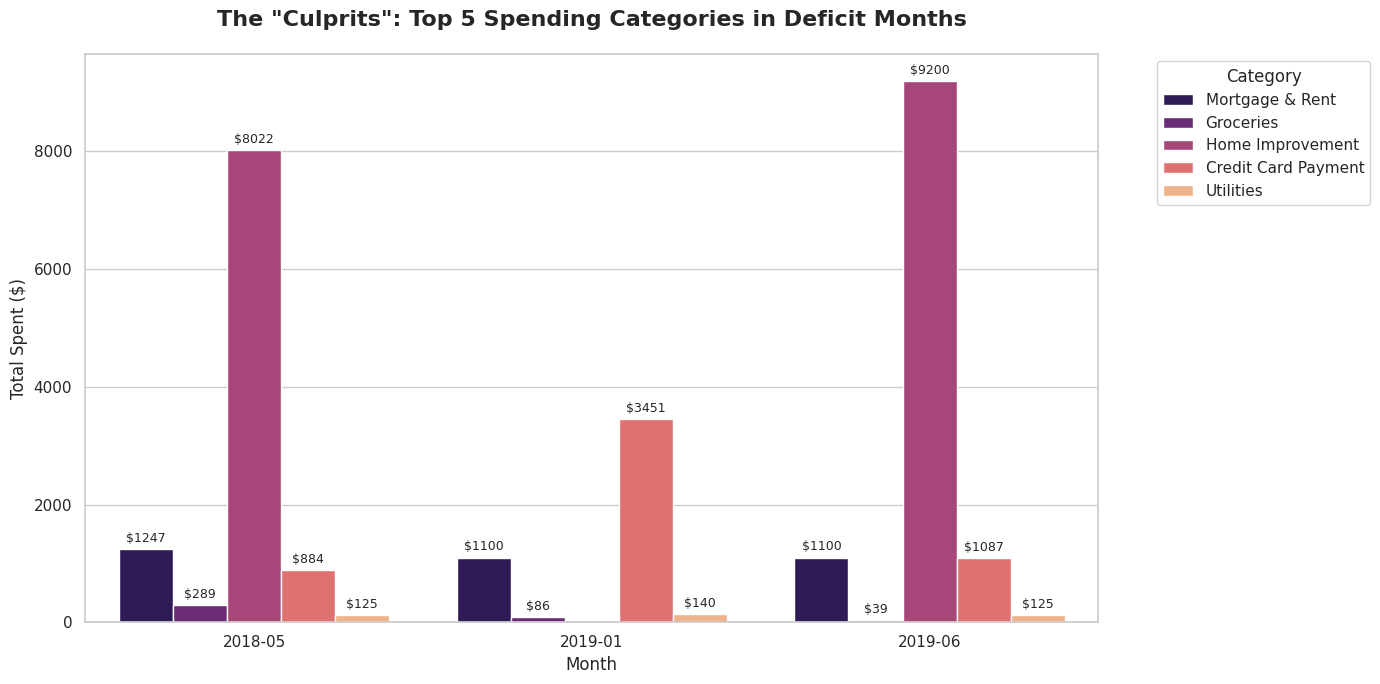

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the months with significant deficits
trouble_months = ['2018-05', '2019-01', '2019-06']

# 2. Filter the original data for these months and only 'debit' transactions
drill_down = df[(df['Month'].astype(str).isin(trouble_months)) & (df['Transaction Type'].str.lower() == 'debit')].copy()

# 3. Get the Top 5 categories overall across these specific months to keep the chart clean
top_cats = drill_down.groupby('Category')['Amount'].sum().sort_values(ascending=False).head(5).index
filtered_drill_down = drill_down[drill_down['Category'].isin(top_cats)]

# 4. Create the Visualization
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Grouped Bar Chart: X = Month, Y = Amount, Hue = Category
ax = sns.barplot(
    data=filtered_drill_down,
    x='Month',
    y='Amount',
    hue='Category',
    estimator=sum,
    errorbar=None,
    palette='magma'
)

# 5. Professional Formatting
plt.title('The "Culprits": Top 5 Spending Categories in Deficit Months', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Total Spent ($)', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add values on top of bars for that "Pro Analyst" look
for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()